In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models
import matplotlib.pyplot as plt
from torchsummary import summary
import copy

In [3]:
# === Check Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
# === Hyperparameters ===
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001
NUM_CLASSES = 10

# === Dataset (CIFAR-10) ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Required for ResNet, MobileNet
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

100%|████████████████████████████████████████████████████████████████████████████████| 170M/170M [02:51<00:00, 992kB/s]


In [5]:
# === Small CNN ===
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 54 * 54, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [B, 32, 111, 111]
        x = self.pool(F.relu(self.conv2(x)))  # [B, 64, 54, 54]
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [6]:
# === Training & Evaluation ===
def train_model(model, trainloader, testloader, epochs, optimizer, criterion):
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        val_loss = val_loss / total
        val_acc = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Train Acc: {train_acc:.4f} Val Acc: {val_acc:.4f}")

    return history

In [7]:
# === Prepare Pretrained Models ===
def prepare_finetune_model(model, num_classes):
    for param in model.parameters():
        param.requires_grad = False
    if isinstance(model, models.ResNet):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif isinstance(model, models.MobileNetV2):
        model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    for param in model.parameters():
        param.requires_grad = True
    return model

In [8]:
# === Load Models ===
resnet = models.resnet18(pretrained=True)
mobilenet = models.mobilenet_v2(pretrained=True)
resnet = prepare_finetune_model(resnet, NUM_CLASSES)
mobilenet = prepare_finetune_model(mobilenet, NUM_CLASSES)

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:27<00:00, 1.70MB/s]
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\User/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████████████████████████████████████████████████████████████████████████| 13.6M/13.6M [00:16<00:00, 878kB/s]


In [9]:
# === Train and Evaluate All Models ===
small_cnn = SmallCNN(NUM_CLASSES)
opt_small = optim.Adam(small_cnn.parameters(), lr=LR)
hist_small = train_model(small_cnn, trainloader, testloader, EPOCHS, opt_small, nn.CrossEntropyLoss())

opt_resnet = optim.Adam(resnet.parameters(), lr=LR)
hist_resnet = train_model(resnet, trainloader, testloader, EPOCHS, opt_resnet, nn.CrossEntropyLoss())

opt_mobile = optim.Adam(mobilenet.parameters(), lr=LR)
hist_mobile = train_model(mobilenet, trainloader, testloader, EPOCHS, opt_mobile, nn.CrossEntropyLoss())

# Save teacher models
resnet_teacher = copy.deepcopy(resnet)
mobilenet_teacher = copy.deepcopy(mobilenet)

Epoch [1/10] Train Loss: 1.6338 Val Loss: 1.4384 Train Acc: 0.4263 Val Acc: 0.4864
Epoch [2/10] Train Loss: 1.3930 Val Loss: 1.3770 Train Acc: 0.5058 Val Acc: 0.5044
Epoch [3/10] Train Loss: 1.2896 Val Loss: 1.3510 Train Acc: 0.5409 Val Acc: 0.5215
Epoch [4/10] Train Loss: 1.2029 Val Loss: 1.3161 Train Acc: 0.5738 Val Acc: 0.5368
Epoch [5/10] Train Loss: 1.1180 Val Loss: 1.3082 Train Acc: 0.6032 Val Acc: 0.5402
Epoch [6/10] Train Loss: 1.0360 Val Loss: 1.3416 Train Acc: 0.6329 Val Acc: 0.5324
Epoch [7/10] Train Loss: 0.9614 Val Loss: 1.3471 Train Acc: 0.6604 Val Acc: 0.5491
Epoch [8/10] Train Loss: 0.8778 Val Loss: 1.4107 Train Acc: 0.6878 Val Acc: 0.5373
Epoch [9/10] Train Loss: 0.7923 Val Loss: 1.4689 Train Acc: 0.7186 Val Acc: 0.5468
Epoch [10/10] Train Loss: 0.7069 Val Loss: 1.5522 Train Acc: 0.7503 Val Acc: 0.5371
Epoch [1/10] Train Loss: 0.5625 Val Loss: 0.5500 Train Acc: 0.8069 Val Acc: 0.8123
Epoch [2/10] Train Loss: 0.3222 Val Loss: 0.3602 Train Acc: 0.8895 Val Acc: 0.8794
Epo

In [30]:
model = small_cnn.to(device)
print("\nModel Summary:")
summary(model, input_size=(3, 224, 224))  # Adjust input size as needed


Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 222, 222]             896
         MaxPool2d-2         [-1, 32, 111, 111]               0
            Conv2d-3         [-1, 64, 109, 109]          18,496
         MaxPool2d-4           [-1, 64, 54, 54]               0
            Linear-5                  [-1, 128]      23,888,000
            Linear-6                   [-1, 10]           1,290
Total params: 23,908,682
Trainable params: 23,908,682
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 22.27
Params size (MB): 91.20
Estimated Total Size (MB): 114.05
----------------------------------------------------------------


In [10]:
# === Knowledge Distillation (single teacher) ===
class DistillLoss(nn.Module):
    def __init__(self, alpha=0.5, temperature=3.0):
        super(DistillLoss, self).__init__()
        self.alpha = alpha
        self.temperature = temperature
        self.ce = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, labels):
        loss_ce = self.ce(student_logits, labels)
        loss_kl = F.kl_div(
            F.log_softmax(student_logits / self.temperature, dim=1),
            F.softmax(teacher_logits / self.temperature, dim=1),
            reduction='batchmean'
        ) * (self.temperature ** 2)
        return self.alpha * loss_ce + (1 - self.alpha) * loss_kl

In [11]:
def distill(student_model, teacher_model, trainloader, testloader, epochs):
    student_model.to(device)
    teacher_model.to(device)
    teacher_model.eval()
    criterion = DistillLoss()
    optimizer = optim.Adam(student_model.parameters(), lr=LR)
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        student_model.train()
        running_loss = 0.0
        correct, total = 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            with torch.no_grad():
                teacher_output = teacher_model(inputs)
            student_output = student_model(inputs)
            loss = criterion(student_output, teacher_output, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = student_output.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        val_acc = evaluate(student_model, testloader)
        history['train_loss'].append(running_loss / total)
        history['val_acc'].append(val_acc)
        print(f"[Distill Epoch {epoch+1}] Loss: {running_loss/total:.4f}, Val Acc: {val_acc:.4f}")

    return history

In [12]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return correct / total

In [13]:
# Distill from one model
student_one = SmallCNN(NUM_CLASSES)
hist_distill_one = distill(student_one, resnet_teacher, trainloader, testloader, EPOCHS)

[Distill Epoch 1] Loss: 6.8012, Val Acc: 0.4994
[Distill Epoch 2] Loss: 5.7123, Val Acc: 0.5200
[Distill Epoch 3] Loss: 5.2572, Val Acc: 0.5314
[Distill Epoch 4] Loss: 4.9108, Val Acc: 0.5448
[Distill Epoch 5] Loss: 4.5530, Val Acc: 0.5546
[Distill Epoch 6] Loss: 4.2079, Val Acc: 0.5537
[Distill Epoch 7] Loss: 3.8731, Val Acc: 0.5539
[Distill Epoch 8] Loss: 3.5177, Val Acc: 0.5536
[Distill Epoch 9] Loss: 3.1666, Val Acc: 0.5497
[Distill Epoch 10] Loss: 2.8225, Val Acc: 0.5532


In [14]:
# Distill from both models (average logits)
class TwoTeacherLoss(nn.Module):
    def __init__(self, alpha=0.5, temperature=3.0):
        super(TwoTeacherLoss, self).__init__()
        self.alpha = alpha
        self.temperature = temperature
        self.ce = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits1, teacher_logits2, labels):
        avg_teacher_logits = (teacher_logits1 + teacher_logits2) / 2
        loss_ce = self.ce(student_logits, labels)
        loss_kl = F.kl_div(
            F.log_softmax(student_logits / self.temperature, dim=1),
            F.softmax(avg_teacher_logits / self.temperature, dim=1),
            reduction='batchmean'
        ) * (self.temperature ** 2)
        return self.alpha * loss_ce + (1 - self.alpha) * loss_kl

In [15]:
def distill_two(student_model, teacher1, teacher2, trainloader, testloader, epochs):
    student_model.to(device)
    teacher1.to(device)
    teacher2.to(device)
    teacher1.eval()
    teacher2.eval()
    criterion = TwoTeacherLoss()
    optimizer = optim.Adam(student_model.parameters(), lr=LR)
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        student_model.train()
        running_loss = 0.0
        correct, total = 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            with torch.no_grad():
                t1 = teacher1(inputs)
                t2 = teacher2(inputs)
            s = student_model(inputs)
            loss = criterion(s, t1, t2, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = s.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        val_acc = evaluate(student_model, testloader)
        history['train_loss'].append(running_loss / total)
        history['val_acc'].append(val_acc)
        print(f"[2-T Distill Epoch {epoch+1}] Loss: {running_loss/total:.4f}, Val Acc: {val_acc:.4f}")

    return history

In [16]:
student_two = SmallCNN(NUM_CLASSES)
hist_distill_two = distill_two(student_two, resnet_teacher, mobilenet_teacher, trainloader, testloader, EPOCHS)


[2-T Distill Epoch 1] Loss: 6.4831, Val Acc: 0.5042
[2-T Distill Epoch 2] Loss: 5.4005, Val Acc: 0.5257
[2-T Distill Epoch 3] Loss: 4.9597, Val Acc: 0.5242
[2-T Distill Epoch 4] Loss: 4.6256, Val Acc: 0.5466
[2-T Distill Epoch 5] Loss: 4.3519, Val Acc: 0.5524
[2-T Distill Epoch 6] Loss: 4.0814, Val Acc: 0.5477
[2-T Distill Epoch 7] Loss: 3.8095, Val Acc: 0.5529
[2-T Distill Epoch 8] Loss: 3.5711, Val Acc: 0.5488
[2-T Distill Epoch 9] Loss: 3.3253, Val Acc: 0.5433
[2-T Distill Epoch 10] Loss: 3.0895, Val Acc: 0.5393


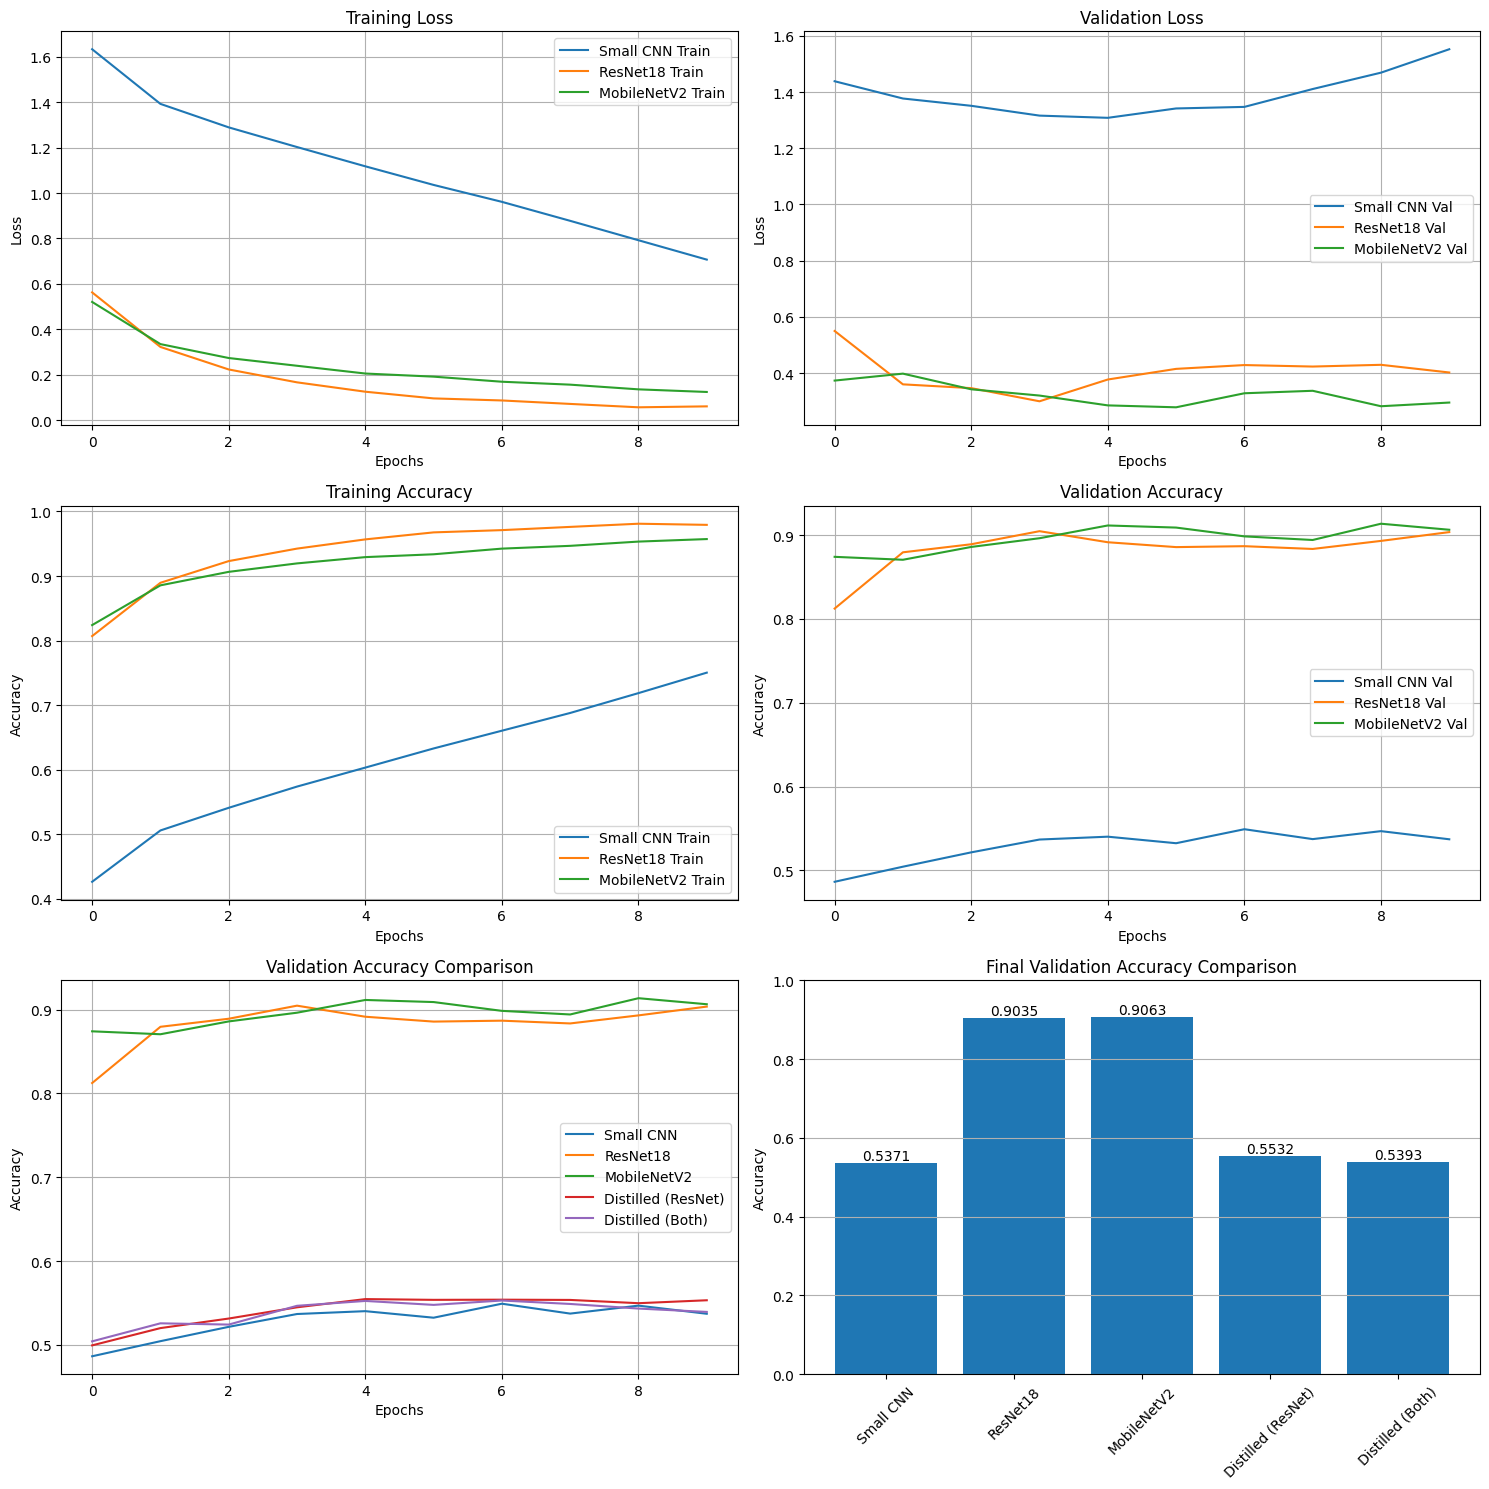

In [25]:
# === Visualization ===
plt.figure(figsize=(15, 15))

# Plot 1: Training Loss for all models
plt.subplot(3, 2, 1)
plt.plot(hist_small['train_loss'], label='Small CNN Train')
plt.plot(hist_resnet['train_loss'], label='ResNet18 Train')
plt.plot(hist_mobile['train_loss'], label='MobileNetV2 Train')
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# Plot 2: Validation Loss for all models
plt.subplot(3, 2, 2)
plt.plot(hist_small['val_loss'], label='Small CNN Val')
plt.plot(hist_resnet['val_loss'], label='ResNet18 Val')
plt.plot(hist_mobile['val_loss'], label='MobileNetV2 Val')
plt.title("Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# Plot 3: Training Accuracy for all models
plt.subplot(3, 2, 3)
plt.plot(hist_small['train_acc'], label='Small CNN Train')
plt.plot(hist_resnet['train_acc'], label='ResNet18 Train')
plt.plot(hist_mobile['train_acc'], label='MobileNetV2 Train')
plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Plot 4: Validation Accuracy for all models
plt.subplot(3, 2, 4)
plt.plot(hist_small['val_acc'], label='Small CNN Val')
plt.plot(hist_resnet['val_acc'], label='ResNet18 Val')
plt.plot(hist_mobile['val_acc'], label='MobileNetV2 Val')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Plot 3: Comparison of Validation Accuracy (All models)
plt.subplot(3, 2, 5)
plt.plot(hist_small['val_acc'], label='Small CNN')
plt.plot(hist_resnet['val_acc'], label='ResNet18')
plt.plot(hist_mobile['val_acc'], label='MobileNetV2')
plt.plot(hist_distill_one['val_acc'], label='Distilled (ResNet)')
plt.plot(hist_distill_two['val_acc'], label='Distilled (Both)')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Plot 4: Final Performance Comparison (Bar chart)
models = ['Small CNN', 'ResNet18', 'MobileNetV2', 'Distilled (ResNet)', 'Distilled (Both)']
final_acc = [
    hist_small['val_acc'][-1],
    hist_resnet['val_acc'][-1],
    hist_mobile['val_acc'][-1],
    hist_distill_one['val_acc'][-1],
    hist_distill_two['val_acc'][-1]
]

plt.subplot(3, 2, 6)
bars = plt.bar(models, final_acc)
plt.title("Final Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()